<a href="https://colab.research.google.com/github/Srivaibhav4014e/Data-science-/blob/main/Full%20Centrality%20%26%20PageRank%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Node  Degree  Betweenness  Closeness  Eigenvector  PageRank
   A     1.2       0.3000     0.7143       0.5127    0.2272
   B     0.8       0.0417     0.5000       0.2058    0.0894
   C     1.2       0.1583     0.7143       0.4516    0.1920
   D     1.0       0.0917     0.7143       0.4193    0.1658
   E     1.0       0.1417     0.7143       0.4064    0.1819
   F     0.8       0.0667     0.6250       0.3871    0.1438

=== Most Important Node ===
Degree         : A (1.2000)
Betweenness    : A (0.3000)
Closeness      : A (0.7143)
PageRank       : A (0.2272)


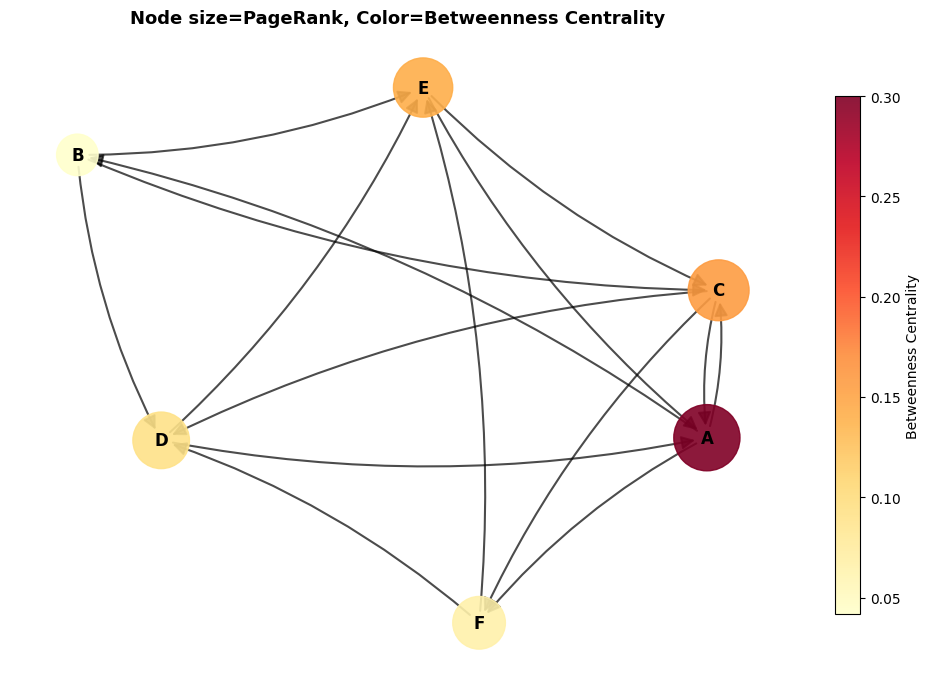

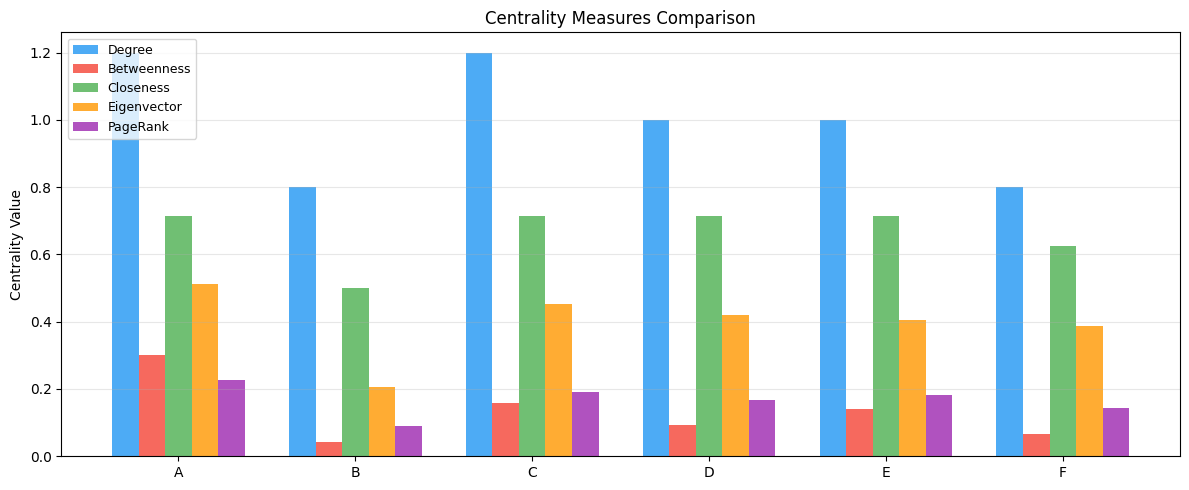

In [1]:

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# ── Build Graph ──────────────────────────────────
G = nx.DiGraph()    # Directed graph for PageRank
edges = [
    ('A','B'),('A','C'),('B','D'),('B','E'),
    ('C','D'),('D','E'),('E','A'),('C','F'),
    ('F','D'),('D','A'),('E','C'),('B','C'),
    ('F','E'),('A','F'),('C','A'),
]
G.add_edges_from(edges)

# ── Compute All Centrality Measures ──────────────
deg_c = nx.degree_centrality(G)                        # O(n)
bet_c = nx.betweenness_centrality(G, normalized=True)  # O(n²)
clo_c = nx.closeness_centrality(G)                     # O(n²)
eig_c = nx.eigenvector_centrality(G, max_iter=1000)    # O(n³)
pr    = nx.pagerank(G, alpha=0.85, max_iter=100)       # Iterative

# ── Display as Table ─────────────────────────────
nodes = sorted(G.nodes())
df = pd.DataFrame({
    'Node'      : nodes,
    'Degree'    : [round(deg_c[n],4) for n in nodes],
    'Betweenness': [round(bet_c[n],4) for n in nodes],
    'Closeness' : [round(clo_c[n],4) for n in nodes],
    'Eigenvector': [round(eig_c[n],4) for n in nodes],
    'PageRank'  : [round(pr[n],4) for n in nodes],
})
print(df.to_string(index=False))

print('\n=== Most Important Node ===')
for measure, scores in [('Degree',deg_c),('Betweenness',bet_c),
                         ('Closeness',clo_c),('PageRank',pr)]:
    top = max(scores, key=scores.get)
    print(f'{measure:15s}: {top} ({scores[top]:.4f})')

# ── Visualize: size=PageRank, color=Betweenness ──
plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)

node_sizes  = [pr[n]*10000 for n in G.nodes()]
node_colors = [bet_c[n] for n in G.nodes()]

nc = nx.draw_networkx_nodes(G, pos,
     node_size=node_sizes, node_color=node_colors,
     cmap=plt.cm.YlOrRd, alpha=0.9)
nx.draw_networkx_edges(G, pos, arrows=True,
     arrowsize=20, width=1.5, alpha=0.7,
     connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
plt.colorbar(nc, label='Betweenness Centrality', shrink=0.8)
plt.title('Node size=PageRank, Color=Betweenness Centrality',
           fontsize=13, fontweight='bold')
plt.axis('off'); plt.tight_layout(); plt.show()

# ── Bar Chart Comparison ─────────────────────────
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(nodes))
w = 0.15
measures = [('Degree',deg_c,'#2196F3'),
            ('Betweenness',bet_c,'#F44336'),
            ('Closeness',clo_c,'#4CAF50'),
            ('Eigenvector',eig_c,'#FF9800'),
            ('PageRank',pr,'#9C27B0')]

for i, (name, data, color) in enumerate(measures):
    vals = [data[n] for n in nodes]
    ax.bar(x + (i-2)*w, vals, w, label=name, color=color, alpha=0.8)

ax.set_xticks(x); ax.set_xticklabels(nodes)
ax.legend(loc='upper left', fontsize=9)
ax.set_title('Centrality Measures Comparison')
ax.set_ylabel('Centrality Value')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()